# 📌 Step 1: Loading Floor Plan Images

In this step, we will:
- Load floor plan images from our dataset
- Display them using OpenCV and Matplotlib

This helps us understand:
- Image quality
- Layout structure
- Preprocessing needs

Available files: ['10Marla_GF_FP_001_V01.png', '10Marla_GF_FP_001_V02.png', '10Marla_GF_FP_001_V03.png', '10Marla_GF_FP_001_V04.png', '10Marla_GF_FP_002_V01.png', '10Marla_GF_FP_002_V02.png', '10Marla_GF_FP_002_V03.png', '10Marla_GF_FP_002_V04.png', '10Marla_GF_FP_003_V01.png', '10Marla_GF_FP_003_V02.png', '10Marla_GF_FP_003_V03.png', '10Marla_GF_FP_003_V04.png', '10Marla_GF_FP_004_V01.png', '10Marla_GF_FP_004_V02.png', '10Marla_GF_FP_004_V03.png', '10Marla_GF_FP_004_V04.png', '10Marla_GF_FP_005_V01.png', '10Marla_GF_FP_005_V02.png', '10Marla_GF_FP_005_V03.png', '10Marla_GF_FP_005_V04.png', '10Marla_GF_FP_006_V01.png', '10Marla_GF_FP_006_V02.png', '10Marla_GF_FP_006_V03.png', '10Marla_GF_FP_006_V04.png', '10Marla_GF_FP_007_V01.png', '10Marla_GF_FP_007_V02.png', '10Marla_GF_FP_007_V03.png', '10Marla_GF_FP_007_V04.png', '10Marla_GF_FP_008_V01.png', '10Marla_GF_FP_008_V02.png', '10Marla_GF_FP_008_V03.png', '10Marla_GF_FP_008_V04.png', '10Marla_GF_FP_009_V01.png', '10Marla_GF_FP_009_V02.pn

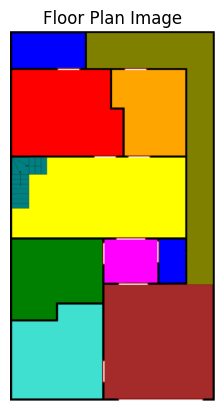

In [3]:
# 📌 Load and Display Floor Plan Image (Single Cell)

import cv2
import matplotlib.pyplot as plt
import os

# Step 1: Check available files
data_path = "../data/raw"
files = os.listdir(data_path)
print("Available files:", files)

# Step 2: Pick first image automatically (no manual mistake)
image_path = os.path.join(data_path, files[0])

# Step 3: Load image
img = cv2.imread(image_path)

# Step 4: Safety check
if img is None:
    print("❌ Error: Image not loaded. Check dataset path.")
else:
    print("✅ Loaded:", files[0])

    # Convert to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display image
    plt.imshow(img_rgb)
    plt.title("Floor Plan Image")
    plt.axis("off")
    plt.show()

# 📌 Step 2: Image Preprocessing

Before detecting rooms, we need to clean the image.

In this step, we:
- Convert image to grayscale
- Apply thresholding
- Detect edges

This helps the model understand room boundaries clearly.

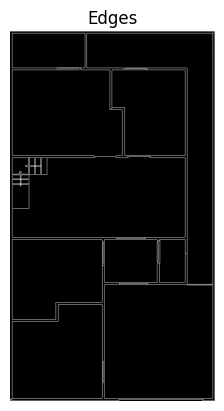

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Thresholding
_, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

# Edge detection
edges = cv2.Canny(gray, 50, 150)

# Show results
plt.imshow(edges, cmap='gray')
plt.title("Edges")
plt.axis("off")
plt.show()

# 📌 Step 3: Room Detection using Contours

We detect rooms by:
- Finding contours in the image
- Filtering large contours (rooms)

Contours represent boundaries of rooms.

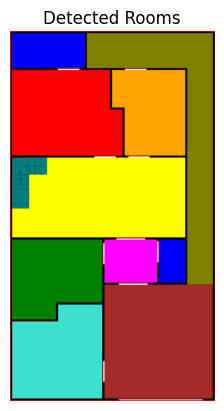

In [5]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

rooms = []

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 5000:  # Filter small noise
        x, y, w, h = cv2.boundingRect(cnt)
        rooms.append((x, y, w, h))

        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (255, 0, 0), 2)

plt.imshow(img_rgb)
plt.title("Detected Rooms")
plt.axis("off")
plt.show()

# 📌 Step 4: Room Area Estimation

We calculate the area of each detected room using bounding boxes.

This gives:
- Approximate room size
- Helps in classification

In [6]:
room_areas = []

for (x, y, w, h) in rooms:
    area = w * h
    room_areas.append(area)

print("Room Areas:", room_areas)

Room Areas: [474112]


In [7]:
def classify_room(area):
    if area > 20000:
        return "Hall"
    elif area > 12000:
        return "Bedroom"
    elif area > 8000:
        return "Kitchen"
    else:
        return "Bathroom"

# 📌 Step 5: Generating Structured Output

We convert results into structured format (JSON).

This makes the system:
- API ready
- Industry standard

In [8]:
import json

output = []

for i, (x, y, w, h) in enumerate(rooms):
    room_data = {
        "room_id": i,
        "area": w * h,
        "type": classify_room(w * h)
    }
    output.append(room_data)

print(json.dumps(output, indent=4))

[
    {
        "room_id": 0,
        "area": 474112,
        "type": "Hall"
    }
]


# 📌 Step 1: Loading Multiple Floor Plan Images

In this step, we:
- Load all images from the dataset folder
- Store them in a list
- Display a few sample images

This helps us verify:
- Dataset is loaded correctly
- Images are readable

In [9]:
import os
import cv2
import matplotlib.pyplot as plt

# Path to dataset
data_path = "../data/raw/"

images = []
image_names = []

# Load all images
for file in os.listdir(data_path):
    if file.endswith(".png") or file.endswith(".jpg"):
        img = cv2.imread(os.path.join(data_path, file))
        images.append(img)
        image_names.append(file)

print("Total Images Loaded:", len(images))

Total Images Loaded: 308


# 📌 Step 2: Visualizing Sample Images

We will display a few images to understand:
- Structure of floor plans
- Color patterns

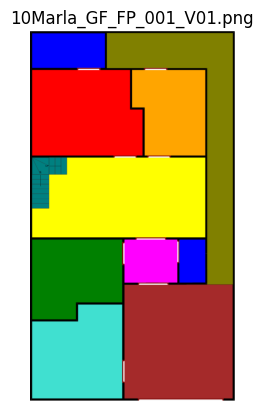

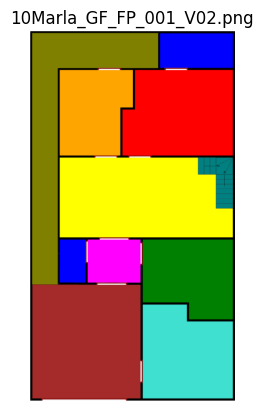

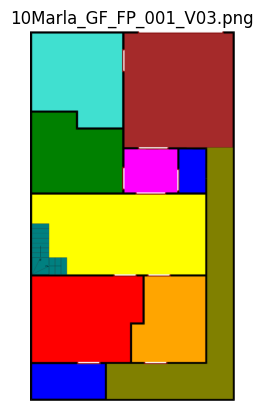

In [10]:
for i in range(3):
    img_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(image_names[i])
    plt.axis("off")
    plt.show()

# 📌 Step 3: Room Detection using Color Segmentation

In this step, we:
- Convert image to RGB
- Identify unique colors
- Extract each colored region as a room

Since each room has a different color, this improves accuracy.

In [11]:
import numpy as np

img = images[0]
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Reshape image to list of pixels
pixels = img_rgb.reshape(-1, 3)

# Get unique colors
unique_colors = np.unique(pixels, axis=0)

print("Total Unique Colors:", len(unique_colors))

Total Unique Colors: 718


# 📌 Step 4: Extracting Rooms Based on Colors

We treat each unique color as a separate room.

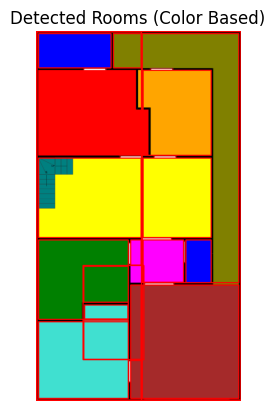

In [12]:
rooms = []

for color in unique_colors:
    # Create mask for each color
    mask = cv2.inRange(img_rgb, color, color)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        area = cv2.contourArea(cnt)

        if area > 1000:  # remove noise
            x, y, w, h = cv2.boundingRect(cnt)
            rooms.append((x, y, w, h))

            cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (255, 0, 0), 2)

plt.imshow(img_rgb)
plt.title("Detected Rooms (Color Based)")
plt.axis("off")
plt.show()

# 📌 Step 5: Counting Total Rooms

We count all detected room regions.

In [14]:
print("Total Rooms Detected:", len(rooms))

Total Rooms Detected: 21
